# 异常检测

在本练习中，你将实现异常检测算法，并将其应用于检测网络中故障的服务器。



# 大纲
- [ 1 - 包 ](#1)
- [ 2 - 异常检测](#2)
  - [ 2.1 问题描述](#2.1)
  - [ 2.2  数据集](#2.2)
  - [ 2.3 Gaussian 分布](#2.3)
    - [ 练习 1](#ex01)
    - [ 练习 2](#ex02)
  - [ 2.4 高维数据集](#2.4)


_**注意：** 为防止自动评分器出错，你不可以编辑或删除本实验中的非评分单元格。请也不要添加任何新的单元格。
**当你通过了本作业**并想尝试任何非评分代码时，可以按照本笔记本底部的说明操作。_

<a name="1"></a>
## 1 - 包

首先，运行下面的单元格以导入本作业所需的所有包。
- [numpy](www.numpy.org) 是 Python 中处理矩阵的基本包。
- [matplotlib](http://matplotlib.org) 是 Python 中用于绘图的知名库。
- ``utils.py`` 包含本作业的辅助函数。你不需要修改此文件中的代码。


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *

%matplotlib inline

<a name="2"></a>
## 2 - 异常检测

<a name="2.1"></a>
### 2.1 问题描述

在本练习中，你将实现一个异常检测算法来
检测服务器计算机中的异常行为。

数据集包含两个特征 -
   * 吞吐量 (mb/s) 和
   * 每台服务器响应的延迟 (ms)。

在服务器运行期间，你收集了 $m=307$ 个服务器行为的样本，因此拥有一个未标记的数据集 $\{x^{(1)}, \ldots, x^{(m)}\}$。
* 你怀疑绝大多数样本是服务器正常运行的"正常"（非异常）样本，但在此数据集中也可能存在一些服务器异常行为的样本。

你将使用 Gaussian 模型来检测数据集中的异常样本。
* 你将首先从一个二维数据集开始，这将使你能够可视化算法的工作过程。
* 在该数据集上，你将拟合一个 Gaussian 分布，然后找到概率非常低的值，这些值可被视为异常。
* 之后，你将把异常检测算法应用于一个具有更多维度的较大数据集。

<a name="2.2"></a>
### 2.2  数据集

你将首先加载此任务的数据集。
- 下面的 `load_data()` 函数将数据加载到变量 `X_train`、`X_val` 和 `y_val` 中
    - 你将使用 `X_train` 来拟合 Gaussian 分布
    - 你将使用 `X_val` 和 `y_val` 作为交叉验证集来选择阈值，并确定异常样本与正常样本

In [2]:
# 加载数据集
X_train, X_val, y_val = load_data()

#### 查看变量
让我们更熟悉你的数据集。
- 一个好的开始方式是打印出每个变量，看看它包含什么。

下面的代码打印每个变量的前五个元素

In [3]:
# 显示 X_train 的前五个元素
print("The first 5 elements of X_train are:\n", X_train[:5])  

The first 5 elements of X_train are:
 [[13.04681517 14.74115241]
 [13.40852019 13.7632696 ]
 [14.19591481 15.85318113]
 [14.91470077 16.17425987]
 [13.57669961 14.04284944]]


In [4]:
# 显示 X_val 的前五个元素
print("The first 5 elements of X_val are\n", X_val[:5])  

The first 5 elements of X_val are
 [[15.79025979 14.9210243 ]
 [13.63961877 15.32995521]
 [14.86589943 16.47386514]
 [13.58467605 13.98930611]
 [13.46404167 15.63533011]]


In [5]:
# 显示 y_val 的前五个元素
print("The first 5 elements of y_val are\n", y_val[:5])  

The first 5 elements of y_val are
 [0 0 0 0 0]


#### 检查变量的维度

另一种熟悉数据的有效方式是查看其维度。

下面的代码打印 `X_train`、`X_val` 和 `y_val` 的形状。

In [6]:
print ('The shape of X_train is:', X_train.shape)
print ('The shape of X_val is:', X_val.shape)
print ('The shape of y_val is: ', y_val.shape)

The shape of X_train is: (307, 2)
The shape of X_val is: (307, 2)
The shape of y_val is:  (307,)


#### 可视化你的数据

在开始任何任务之前，通过可视化来理解数据通常很有用。
- 对于这个数据集，你可以使用散点图来可视化数据（`X_train`），因为它只有两个属性可以绘制（吞吐量和延迟）

- 你的图应与下图类似
<img src="images/figure1.png" width="500" height="500">

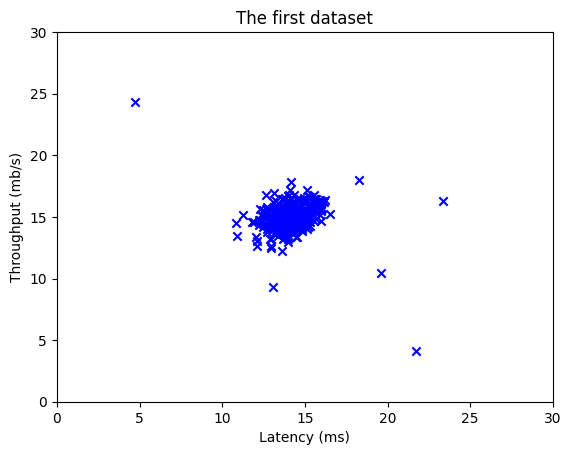

In [7]:
# 创建数据的散点图。要将标记更改为蓝色 "x",
# 我们使用了 'marker' 和 'c' 参数
plt.scatter(X_train[:, 0], X_train[:, 1], marker='x', c='b') 

# 设置标题
plt.title("The first dataset")
# 设置 y 轴标签
plt.ylabel('Throughput (mb/s)')
# 设置 x 轴标签
plt.xlabel('Latency (ms)')
# 设置坐标轴范围
plt.axis([0, 30, 0, 30])
plt.show()

<a name="2.3"></a>
### 2.3 Gaussian 分布

要执行异常检测，你首先需要将模型拟合到数据的分布。

* 给定一个训练集 $\{x^{(1)}, ..., x^{(m)}\}$，你需要估计每个特征 $x_i$ 的 Gaussian 分布。

* 回顾一下，Gaussian 分布的公式为

   $$ p(x ; \mu,\sigma ^2) = \frac{1}{\sqrt{2 \pi \sigma ^2}}\exp^{ - \frac{(x - \mu)^2}{2 \sigma ^2} }$$

   其中 $\mu$ 是均值，$\sigma^2$ 是方差。
   
* 对于每个特征 $i = 1\ldots n$，你需要找到拟合第 $i$ 维数据 $\{x_i^{(1)}, ..., x_i^{(m)}\}$（每个样本的第 $i$ 维）的参数 $\mu_i$ 和 $\sigma_i^2$。

### 2.3.1 估计 Gaussian 分布的参数

**实现**：

你的任务是完成下面 `estimate_gaussian` 中的代码。

<a name="ex01"></a>
### 练习 1

请完成下面的 `estimate_gaussian` 函数，计算 `mu`（`X` 中每个特征的均值）和 `var`（`X` 中每个特征的方差）。

你可以使用以下公式估计第 $i$ 个特征的参数（$\mu_i$, $\sigma_i^2$）。要估计均值，你将使用：

$$\mu_i = \frac{1}{m} \sum_{j=1}^m x_i^{(j)}$$

对于方差，你将使用：
$$\sigma_i^2 = \frac{1}{m} \sum_{j=1}^m (x_i^{(j)} - \mu_i)^2$$

如果你遇到困难，可以查看下面单元格之后的提示来帮助你实现。

In [8]:
# UNQ_C1
# GRADED FUNCTION: estimate_gaussian

def estimate_gaussian(X): 
    """
    计算数据集中所有特征的均值和方差
    
    参数:
        X (ndarray): (m, n) 数据矩阵
    
    返回:
        mu (ndarray): (n,) 所有特征的均值
        var (ndarray): (n,) 所有特征的方差
    """

    m, n = X.shape
    
    ### START CODE HERE ### 
    mu = np.sum(X, axis = 0) / m
    var = np.sum((X - mu) ** 2, axis = 0) / m 
    ### END CODE HERE ### 
        
    return mu, var

<details>
  <summary><font size="3" color="darkgreen"><b>点击查看提示</b></font></summary>
  
   * 你可以通过两种方式实现此函数：
      * 1 - 使用两个嵌套 for 循环 - 一个遍历 `X` 的**列**（每个特征），然后遍历每个数据点。
      * 2 - 使用 `np.sum()` 并设置 `axis = 0` 参数以向量化方式实现（因为我们想要每列的总和）

    
   * 以下是向量化实现中此函数整体实现的结构：
     ```python  
    def estimate_gaussian(X): 
        m, n = X.shape
    
        ### START CODE HERE ### 
        mu = # 你的代码：计算每个特征的均值
        var = # 你的代码：计算每个特征的方差
        ### END CODE HERE ### 
        
        return mu, var
    ```

    如果你仍然遇到困难，可以查看下面的提示来计算 `mu` 和 `var`。
    
    <details>
          <summary><font size="2" color="darkblue"><b>计算 mu 的提示</b></font></summary>
           &emsp; &emsp; 你可以使用 <a href="https://numpy.org/doc/stable/reference/generated/numpy.sum.html">np.sum</a> 并设置 `axis = 0` 参数来获取数组每列的总和
          <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; 计算 mu 的更多提示</b></font></summary>
               &emsp; &emsp; 你可以这样计算 mu：<code>mu = 1 / m * np.sum(X, axis = 0)</code>
           </details>
    </details>
    
    <details>
          <summary><font size="2" color="darkblue"><b>计算 var 的提示</b></font></summary>
           &emsp; &emsp; 你可以使用 <a href="https://numpy.org/doc/stable/reference/generated/numpy.sum.html">np.sum</a> 并设置 `axis = 0` 参数来获取数组每列的总和，并使用 <code>**2</code> 来获取平方。
          <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; 计算 var 的更多提示</b></font></summary>
               &emsp; &emsp; 你可以这样计算 var：<code> var = 1 / m * np.sum((X - mu) ** 2, axis = 0)</code>
           </details>
    </details>
    
</details>

你可以通过运行以下测试代码来检查你的实现是否正确：

In [9]:
# 估计每个特征的均值和方差
mu, var = estimate_gaussian(X_train)              

print("Mean of each feature:", mu)
print("Variance of each feature:", var)
    
# 单元测试
from public_tests import *
estimate_gaussian_test(estimate_gaussian)

Mean of each feature: [14.11222578 14.99771051]
Variance of each feature: [1.83263141 1.70974533]
所有测试通过！


**预期输出**：
<table>
  <tr>
    <td> <b>Mean of each feature: <b>  </td> 
    <td> [14.11222578 14.99771051]</td> 
   </tr>    
   <tr>
    <td> <b>Variance of each feature: <b>  </td>
     <td> [1.83263141 1.70974533] </td> 
  </tr>
</table>

既然你已经完成了 `estimate_gaussian` 中的代码，我们将可视化拟合的 Gaussian 分布的等高线。

你应该得到一个与下图类似的图。
<img src="images/figure2.png" width="500" height="500">


从图中可以看到，大多数样本位于概率最高的区域，而异常样本位于概率较低的区域。

/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 21534 (\N{CJK UNIFIED IDEOGRAPH-541E}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 21520 (\N{CJK UNIFIED IDEOGRAPH-5410}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 25311 (\N{CJK UNIFIED IDEOGRAPH-62DF}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/

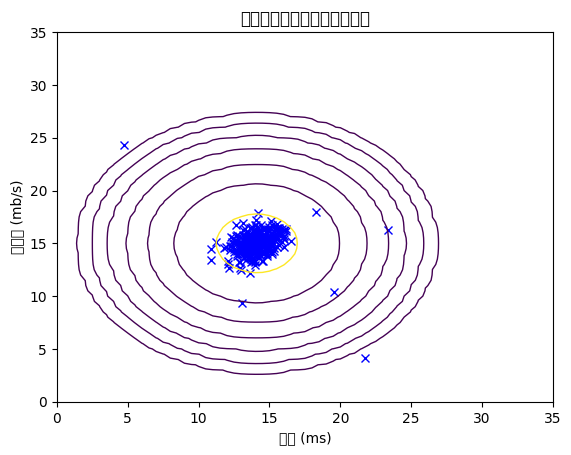

In [10]:
# 返回多元正态分布在
# X_train 每个数据点（行）处的密度
p = multivariate_gaussian(X_train, mu, var)

# 绘图代码
visualize_fit(X_train, mu, var)

### 2.3.2 选择阈值 $\epsilon$

既然你已经估计了 Gaussian 参数，你可以研究哪些样本在此分布下具有非常高的概率，哪些样本具有非常低的概率。

* 低概率的样本更可能是我们数据集中的异常。
* 确定哪些样本是异常的一种方法是基于交叉验证集选择一个阈值。

在本节中，你将完成 `select_threshold` 中的代码，使用交叉验证集上的 $F_1$ 分数来选择阈值 $\varepsilon$。

* 为此，我们将使用一个交叉验证集
$\{(x_{\rm cv}^{(1)}, y_{\rm cv}^{(1)}),\ldots, (x_{\rm cv}^{(m_{\rm cv})}, y_{\rm cv}^{(m_{\rm cv})})\}$，其中标签 $y=1$ 对应异常样本，$y=0$ 对应正常样本。
* 对于每个交叉验证样本，我们将计算 $p(x_{\rm cv}^{(i)})$。所有这些概率 $p(x_{\rm cv}^{(1)}), \ldots, p(x_{\rm cv}^{(m_{\rm cv})})$ 的向量通过 `p_val` 传递给 `select_threshold`。
* 对应的标签 $y_{\rm cv}^{(1)}, \ldots, y_{\rm cv}^{(m_{\rm cv})}$ 通过 `y_val` 传递给同一函数。

<a name="ex02"></a>
### 练习 2
请完成下面的 `select_threshold` 函数，根据验证集（`p_val`）和真实标签（`y_val`）的结果找到用于选择异常值的最佳阈值。

* 在提供的代码 `select_threshold` 中，已经有一个循环将尝试许多不同的 $\varepsilon$ 值，并基于 $F_1$ 分数选择最佳的 $\varepsilon$。

* 你需要实现代码来计算选择 `epsilon` 作为阈值的 F1 分数，并将值放入 `F1` 中。

  * 回顾一下，如果样本 $x$ 的概率较低 $p(x) < \varepsilon$，则它被分类为异常。
        
  * 然后，你可以通过以下方式计算精确率和召回率：
   $$\begin{aligned}
   prec&=&\frac{tp}{tp+fp}\\
   rec&=&\frac{tp}{tp+fn},
   \end{aligned}$$ 其中
    * $tp$ 是真正例的数量：真实标签表明它是异常，我们的算法正确地将其分类为异常。
    * $fp$ 是假正例的数量：真实标签表明它不是异常，但我们的算法错误地将其分类为异常。
    * $fn$ 是假负例的数量：真实标签表明它是异常，但我们的算法错误地将其分类为非异常。

  * $F_1$ 分数使用精确率（$prec$）和召回率（$rec$）计算如下：
    $$F_1 = \frac{2\cdot prec \cdot rec}{prec + rec}$$

**实现说明：**
为了计算 $tp$、$fp$ 和 $fn$，你可以使用向量化实现，而不是循环遍历所有样本。


如果你遇到困难，可以查看下面单元格之后的提示来帮助你实现。

In [11]:
# UNQ_C2
# GRADED FUNCTION: select_threshold

def select_threshold(y_val, p_val): 
    """
    根据验证集的结果和真实标签
    找到用于选择异常值的最佳阈值
    
    参数:
        y_val (ndarray): 验证集上的真实标签
        p_val (ndarray): 验证集上的结果
        
    返回:
        epsilon (float): 选择的阈值
        F1 (float):      选择 epsilon 作为阈值时的 F1 分数
    """ 

    best_epsilon = 0
    best_F1 = 0
    F1 = 0
    
    step_size = (max(p_val) - min(p_val)) / 1000
    
    for epsilon in np.arange(min(p_val), max(p_val), step_size):
    
        ### START CODE HERE ### 
        predictions = (p_val < epsilon)
        
        tp = sum((predictions == 1) & (y_val == 1))
        fp = sum((predictions == 1) & (y_val == 0))
        fn = sum((predictions == 0) & (y_val == 1))
        
        prec = tp / (tp + fp)
        rec = tp / (tp + fn)
        
        F1 = (2 * prec * rec) / (prec + rec)
        ### END CODE HERE ### 
        
        if F1 > best_F1:
            best_F1 = F1
            best_epsilon = epsilon
        
    return best_epsilon, best_F1

<details>
  <summary><font size="3" color="darkgreen"><b>点击查看提示</b></font></summary>

   * 以下是向量化实现中此函数整体实现的结构：
     ```python  
    def select_threshold(y_val, p_val): 
        best_epsilon = 0
        best_F1 = 0
        F1 = 0
    
        step_size = (max(p_val) - min(p_val)) / 1000
    
        for epsilon in np.arange(min(p_val), max(p_val), step_size):
    
            ### START CODE HERE ### 
            predictions = # 你的代码：使用 epsilon 作为阈值计算每个样本的预测
        
            tp = # 你的代码：计算真正例的数量
            fp = # 你的代码：计算假正例的数量
            fn = # 你的代码：计算假负例的数量
        
            prec = # 你的代码：计算精确率
            rec = # 你的代码：计算召回率
        
            F1 = # 你的代码：计算 F1
            ### END CODE HERE ### 
        
            if F1 > best_F1:
                best_F1 = F1
                best_epsilon = epsilon
        
        return best_epsilon, best_F1
    ```

    如果你仍然遇到困难，可以查看下面的提示来计算每个变量。
    
    <details>
          <summary><font size="2" color="darkblue"><b>计算 predictions 的提示</b></font></summary>
           &emsp; &emsp; 如果样本 𝑥 的概率较低 $p(x) < \epsilon$，则它被分类为异常。要获取每个样本的预测值（正常为 0/False，异常为 1/True），你可以使用 <code>predictions = (p_val < epsilon)</code>
    </details>
    
    <details>
          <summary><font size="2" color="darkblue"><b>计算 tp、fp、fn 的提示</b></font></summary>
           &emsp; &emsp; 
        <ul>
          <li>如果你有一个 $n$ 维二值向量中的多个二值值，你可以使用以下方式找出该向量中有多少个值为 0：<code>np.sum(v == 0)</code></li>
          <li>你还可以对这样的二值向量应用逻辑*与*运算符。例如，`predictions` 是一个大小为交叉验证集数量的二值向量，其中第 $i$ 个元素为 1 表示你的算法认为 $x_{\rm cv}^{(i)}$ 是异常，否则为 0。</li>
          <li>然后，例如，你可以使用以下方式计算假正例的数量：
<code>fp = sum((predictions == 1) & (y_val == 0))</code>。</li>
        </ul>
         <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; 计算 tp、fn 的更多提示</b></font></summary>
               &emsp; &emsp;
             <ul>
              <li>你可以这样计算 tp：<code> tp = np.sum((predictions == 1) & (y_val == 1))</code></li>
              <li>你可以这样计算 fn：<code> fn = np.sum((predictions == 0) & (y_val == 1))</code></li>  
              </ul>
          </details>
    </details>
        
    <details>
          <summary><font size="2" color="darkblue"><b>计算精确率的提示</b></font></summary>
           &emsp; &emsp; 你可以这样计算精确率：<code>prec = tp / (tp + fp)</code>
    </details>
        
    <details>
          <summary><font size="2" color="darkblue"><b>计算召回率的提示</b></font></summary>
           &emsp; &emsp; 你可以这样计算召回率：<code>rec = tp / (tp + fn)</code>
    </details>
        
    <details>
          <summary><font size="2" color="darkblue"><b>计算 F1 的提示</b></font></summary>
           &emsp; &emsp; 你可以这样计算 F1：<code>F1 = 2 * prec * rec / (prec + rec)</code>
    </details>
    
</details>

你可以使用下面的代码检查你的实现

In [12]:
p_val = multivariate_gaussian(X_val, mu, var)
epsilon, F1 = select_threshold(y_val, p_val)

print('Best epsilon found using cross-validation: %e' % epsilon)
print('Best F1 on Cross Validation Set: %f' % F1)
    
# 单元测试
select_threshold_test(select_threshold)


/tmp/ipykernel_16702/2884600331.py:33: RuntimeWarning: invalid value encountered in scalar divide
  prec = tp / (tp + fp)


Best epsilon found using cross-validation: 8.990853e-05
Best F1 on Cross Validation Set: 0.875000
所有测试通过！


**预期输出**：
<table>
  <tr>
    <td> <b>Best epsilon found using cross-validation: <b>  </td> 
    <td> 8.99e-05</td> 
   </tr>    
   <tr>
    <td> <b>Best F1 on Cross Validation Set: <b>  </td>
     <td> 0.875 </td> 
  </tr>
</table>

现在我们将运行你的异常检测代码，并在图中圈出异常（下图 Figure 3）。

<img src="images/figure3.png" width="500" height="500">

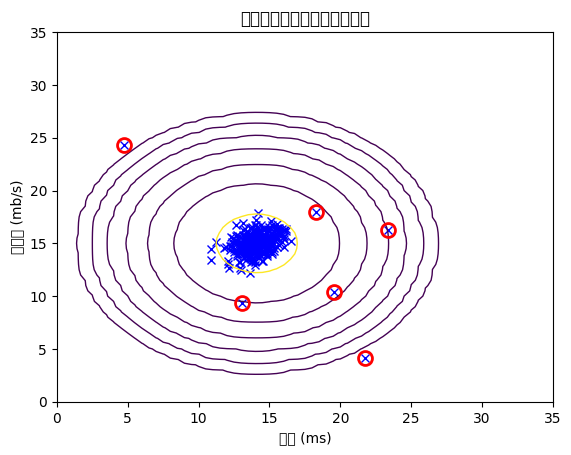

In [13]:
# 在训练集中找到异常值
outliers = p < epsilon

# 可视化拟合结果
visualize_fit(X_train, mu, var)

# 在异常值周围画红色圆圈
plt.plot(X_train[outliers, 0], X_train[outliers, 1], 'ro',
         markersize= 10,markerfacecolor='none', markeredgewidth=2)

<a name="2.4"></a>
### 2.4 高维数据集

现在，我们将在一个更现实且更难的数据集上运行你实现的异常检测算法。

在这个数据集中，每个样本由 11 个特征描述，捕获了你的计算服务器的更多属性。

让我们首先加载数据集。

- 下面的 `load_data()` 函数将数据加载到变量 `X_train_high`、`X_val_high` 和 `y_val_high` 中
    - `_high` 是为了将这些变量与前面部分使用的变量区分开来
    - 我们将使用 `X_train_high` 来拟合 Gaussian 分布
    - 我们将使用 `X_val_high` 和 `y_val_high` 作为交叉验证集来选择阈值，并确定异常样本与正常样本

In [14]:
# 加载数据集
X_train_high, X_val_high, y_val_high = load_data_multi()

#### 检查变量的维度

让我们检查这些新变量的维度以熟悉数据

In [15]:
print ('The shape of X_train_high is:', X_train_high.shape)
print ('The shape of X_val_high is:', X_val_high.shape)
print ('The shape of y_val_high is: ', y_val_high.shape)

The shape of X_train_high is: (1000, 11)
The shape of X_val_high is: (100, 11)
The shape of y_val_high is:  (100,)


#### 异常检测

现在，让我们在这个新数据集上运行异常检测算法。

下面的代码将使用你的代码来
* 估计 Gaussian 参数（$\mu_i$ 和 $\sigma_i^2$）
* 评估训练数据 `X_train_high` 以及交叉验证集 `X_val_high` 的概率，你从中估计了 Gaussian 参数。
* 最后，它将使用 `select_threshold` 来找到最佳阈值 $\varepsilon$。

In [16]:
# 对较大数据集应用相同的步骤

# 估计 Gaussian 参数
mu_high, var_high = estimate_gaussian(X_train_high)

# 评估训练集的概率
p_high = multivariate_gaussian(X_train_high, mu_high, var_high)

# 评估交叉验证集的概率
p_val_high = multivariate_gaussian(X_val_high, mu_high, var_high)

# 找到最佳阈值
epsilon_high, F1_high = select_threshold(y_val_high, p_val_high)

print('Best epsilon found using cross-validation: %e'% epsilon_high)
print('Best F1 on Cross Validation Set:  %f'% F1_high)
print('# Anomalies found: %d'% sum(p_high < epsilon_high))

Best epsilon found using cross-validation: 1.377229e-18
Best F1 on Cross Validation Set:  0.615385
# Anomalies found: 117


/tmp/ipykernel_16702/2884600331.py:33: RuntimeWarning: invalid value encountered in scalar divide
  prec = tp / (tp + fp)


**预期输出**：
<table>
  <tr>
    <td> <b>Best epsilon found using cross-validation: <b>  </td> 
    <td> 1.38e-18</td> 
   </tr>    
   <tr>
    <td> <b>Best F1 on Cross Validation Set: <b>  </td>
     <td> 0.615385 </td> 
  </tr>
    <tr>
    <td> <b># anomalies found: <b>  </td>
     <td>  117 </td> 
  </tr>
</table>

<details>
  <summary><font size="2" color="darkgreen"><b>如果你想尝试任何非评分代码，请点击此处。</b></font></summary>
    <p><i><b>重要说明：请仅在你已经通过作业后才执行此操作，以避免自动评分器出现问题。</b></i>
    <ol>
        <li> 在笔记本的菜单中，点击"View" > "Cell Toolbar" > "Edit Metadata"</li>
        <li> 点击你想要锁定/解锁的代码单元格旁边的"Edit Metadata"按钮</li>
        <li> 将"editable"的属性值设置为：
            <ul>
                <li> "true" 如果你想解锁它</li>
                <li> "false" 如果你想锁定它</li>
            </ul>
        </li>
        <li> 在笔记本的菜单中，点击"View" > "Cell Toolbar" > "None"</li>
    </ol>
    <p> 以下是上述步骤的简短演示：
        <br>
        <img src="https://drive.google.com/uc?export=view&id=14Xy_Mb17CZVgzVAgq7NCjMVBvSae3xO1" align="center" alt="unlock_cells.gif">
</details>